## Market Prior (Implied Returns) Validation — Black–Litterman

### Objective
Derive the **market-implied equilibrium returns** Pi and perform an **equilibrium check**:

- Compute the market prior via

Pi = lambda * Sigma * w_mkt

- Verify mathematical consistency by solving the mean–variance utility problem using (Pi, Sigma, lambda) and recovering w_mkt.

### Universe
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA']

### Notation
- Sigma: (annualized) covariance matrix of returns
- w_mkt: market-cap weights (sum to 1)
- lambda: risk aversion
- Pi: implied equilibrium returns (annualized)


In [4]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we run from project root (so `data/raw` resolves correctly)
if Path.cwd().name in {"notebooks", "research"}:
    os.chdir("..")

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")

CWD: c:\Users\reymo\quant-portfolio


## Step 1 — Data acquisition (Adjusted Close)

We use the project’s storage layer (`DataManager`) to load OHLCV data from `data/raw`. 

We then build a clean price matrix P_t and compute simple daily returns:


R_t = (P_t / P_{t-1}) - 1



In [5]:
from src.data.data_manager import DataManager
from src.analytics.mvo_optimizer import MeanVarianceOptimizer
from src.analytics.black_litterman import BlackLittermanModel
import yfinance as yf

start_date = "2020-01-01"
end_date = "2025-12-31"

dm = DataManager()

tickers = dm.list_existing_tickers()

returns = dm.load_returns(tickers=tickers, start_date=start_date, end_date=end_date)

returns.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
AAPL,1549.0,0.001051,0.019765,-0.128647,-0.007770,0.000581,0.010738,0.153288
ABBV,1549.0,0.000890,0.015508,-0.130023,-0.006358,0.000609,0.008688,0.087174
ADBE,1549.0,0.000310,0.023381,-0.167932,-0.009652,0.000140,0.012298,0.177193
AIR.PA,1549.0,0.000612,0.024875,-0.221685,-0.009700,0.000704,0.010853,0.204633
AMZN,1549.0,0.000824,0.022183,-0.140494,-0.010856,0.000251,0.012404,0.135359


## Step 2 — Covariance Sigma via Ledoit–Wolf shrinkage (project implementation)

We construct Sigma using the same shrinkage routine as the rest of the project (the stabilizer inside MeanVarianceOptimizer).

To keep units consistent with the benchmark return (8% annual), we **annualize** the covariance:

Sigma_ann = 252 * Sigma_daily


In [7]:
mvo = MeanVarianceOptimizer(returns)
delta = mvo.calculate_optimal_delta()

sigma_daily = mvo._apply_ledoit_wolf_shrinkage()
Sigma_daily = pd.DataFrame(sigma_daily, index=tickers, columns=tickers)
Sigma_ann = 252.0 * Sigma_daily

delta, Sigma_ann.round(6).iloc[:3, :3]

(np.float64(0.02042402541565563),
           AAPL      ABBV      ADBE
 AAPL  0.098738  0.021868  0.067889
 ABBV  0.021868  0.061672  0.021965
 ADBE  0.067889  0.021965  0.137255)

## Step 3 — Market weights w_mkt from market caps

We approximate the market portfolio over the universe by using current market capitalizations.


(w_mkt)_i = MktCap_i / (sum of all MktCap_j)


This yields a fully-invested benchmark vector aligned to (Sigma)’s index.


In [8]:
market_caps = dm.get_latest_market_cap(tickers).reindex(tickers)
w_mkt = (market_caps / market_caps.sum()).rename("w_mkt")

market_caps, w_mkt, w_mkt.sum()

(AAPL      4.009957e+12
 ABBV      4.027981e+11
 ADBE      1.475607e+11
 AIR.PA    1.570392e+11
 AMZN      2.496191e+12
 ASML      4.161487e+11
 AVGO      1.658735e+12
 BABA      3.517969e+11
 BNP.PA    9.057124e+10
 CRM       2.531559e+11
 CSCO      3.042263e+11
 CVX       3.045215e+11
 DG.PA     6.687158e+10
 DIS       2.035671e+11
 GOOGL     3.796644e+12
 HD        3.447954e+11
 INTC      1.863202e+11
 JNJ       4.985073e+11
 JPM       8.764806e+11
 KO        3.015580e+11
 LIN       2.008621e+11
 MA        5.151150e+11
 MC.PA     3.172726e+11
 MCD       2.198116e+11
 META      1.684557e+12
 MRK       2.649149e+11
 MSFT      3.623136e+12
 NFLX      3.978044e+11
 NKE       9.058466e+10
 NVDA      4.566036e+12
 NVO       2.277608e+11
 OR.PA     1.958717e+11
 ORCL      5.653052e+11
 PEP       1.971158e+11
 PFE       1.397450e+11
 PG        3.347700e+11
 RIO       1.607302e+11
 RMS.PA    2.224627e+11
 SAN.PA    1.005453e+11
 SAP       2.853862e+11
 SHEL      2.086365e+11
 SU.PA     1.326

## Step 4 — Risk aversion lambda from a benchmark return and market variance

We use the standard CAPM-style approximation:

lambda = (E[R_mkt] - r_f) / Var(R_mkt)

Implementation details:
- E[R_mkt]: set to an annual benchmark return of **8%**.
- Var(R_mkt): estimated from the **variance of the market-portfolio return** of our universe using Sigma_ann:

Var(R_mkt) ≈ w_mkt^T * Sigma_ann * w_mkt


In [13]:
bl = BlackLittermanModel(market_caps, risk_free_rate=0.04)

benchmark_return = 0.08

lam = bl.calculate_risk_aversion(
    benchmark_return=benchmark_return,
    market_caps=market_caps,
    sigma_ann=Sigma_ann
)

pd.Series(
    {
        "rf": bl.rf,
        "benchmark_return": benchmark_return,
        "var_mkt": bl.benchmark_var,
        "lambda": lam,
    }
)

rf                  0.040000
benchmark_return    0.080000
var_mkt             0.065506
lambda              0.610628
dtype: float64

## Step 5 — Market prior (Implied returns) Pi

Given lambda, Sigma, and w_mkt, the equilibrium (market-implied) returns are

Pi = lambda * Sigma * w_mkt

Because we work with pandas objects, the multiplication is performed with **explicit index alignment** (same ticker ordering for Sigma and w_mkt).


In [15]:
Pi_ann = bl.calculate_implied_returns(
    covariance=Sigma_ann, market_weights=w_mkt
)

hist_ann = (returns.mean() * 252.0).rename("Historical Annualized Return")

pd.concat([hist_ann, Pi_ann], axis=1).head()

,Historical Annualized Return,Implied Returns
AAPL,0.264952,0.039667
ABBV,0.224390,0.012198
ADBE,0.078148,0.041129
AIR.PA,0.154105,0.017936
AMZN,0.207722,0.041101


## Step 6 — Equilibrium check (weight recovery)

We now solve the mean–variance utility problem:

maximize: Pi^T * w - (lambda/2) * w^T * Sigma * w
subject to: sum(w) = 1

If Pi = lambda * Sigma * w_mkt and constraints are not binding, the optimizer should recover the market weights:

w_optimized ≈ w_mkt


In [16]:
w_opt = mvo.solve(
    expected_returns=Pi_ann,
    covariance=Sigma_ann,
    risk_aversion=lam,
    long_only=True,
)

comparison = pd.concat([w_mkt.rename("w_mkt"), w_opt.rename("w_optimized")], axis=1)
comparison["abs_diff"] = (comparison["w_optimized"] - comparison["w_mkt"]).abs()

comparison.head(), comparison["abs_diff"].max()

(           w_mkt  w_optimized      abs_diff
 AAPL    0.113270     0.113271  9.367574e-07
 ABBV    0.011378     0.011380  1.916851e-06
 ADBE    0.004168     0.004167  7.785034e-07
 AIR.PA  0.004436     0.004435  1.283831e-06
 AMZN    0.070510     0.070511  1.155899e-06,
 np.float64(1.1148472062376055e-05))

## Step 7 — Visualizations

- **Return comparison**: historical annualized mean vs implied equilibrium return.
- **Weight recovery**: w_mkt vs w_optimized (should match up to numerical tolerance).


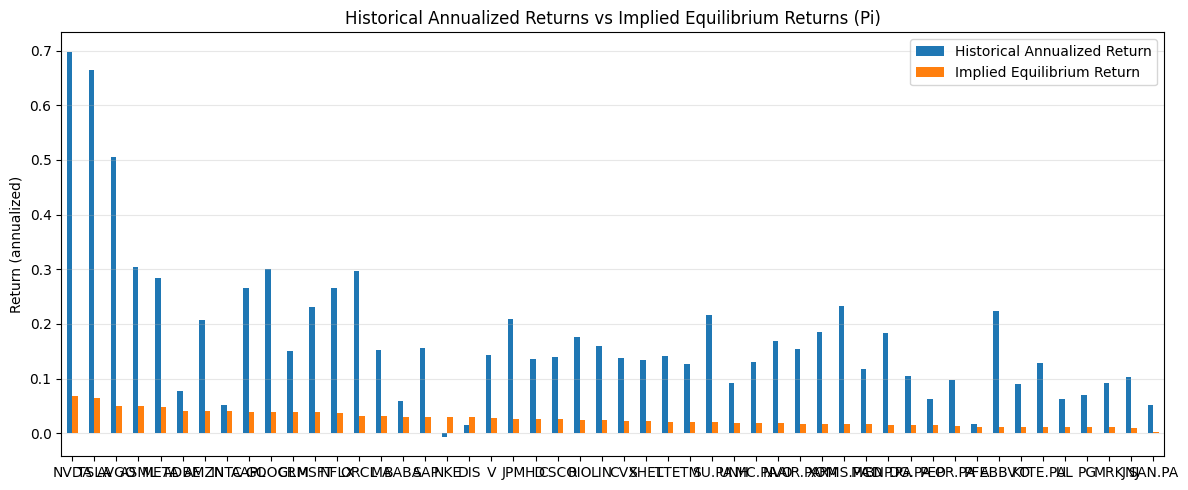

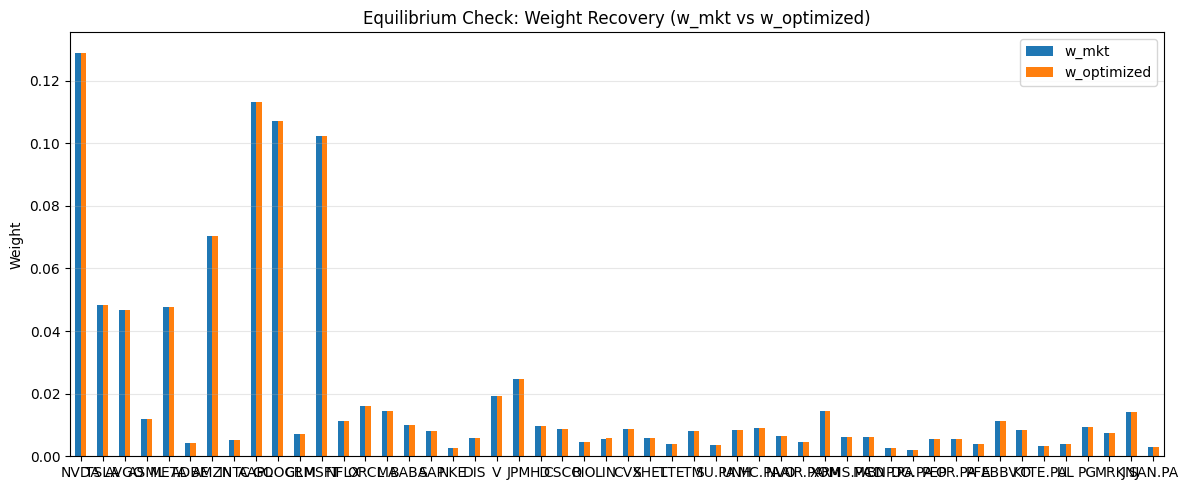

In [17]:
# --- Bar chart: Historical vs Implied ---
plot_df = pd.concat([hist_ann, Pi_ann.rename("Implied Equilibrium Return")], axis=1)
plot_df = plot_df.sort_values("Implied Equilibrium Return", ascending=False)

ax = plot_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("Historical Annualized Returns vs Implied Equilibrium Returns (Pi)")
ax.set_ylabel("Return (annualized)")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Weight recovery chart ---
weights_df = comparison[["w_mkt", "w_optimized"]].copy()
weights_df = weights_df.loc[plot_df.index]  # same ordering as plot above

ax = weights_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("Equilibrium Check: Weight Recovery (w_mkt vs w_optimized)")
ax.set_ylabel("Weight")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation

- If the **max absolute weight error** is near machine precision (e.g., (less than 10^-6)), the equilibrium identity is numerically validated under the project’s constraints.
- If the recovery is imperfect, the usual culprits are:
  - Unit mismatch (daily vs annual inputs),
  - Constraint binding (e.g., long-only causing corner solutions),
  - Index misalignment between (Sigma) and (w).


## Step 8 - Adding Views


In [19]:
tickers = dm.list_existing_tickers()
tau = 0.025
bl = BlackLittermanModel()
# Add Views
# View 1: Absolute - AAPL will return 7%
bl.add_view({"AAPL": 1.0}, 0.07, confidence_score=0.3)

# View 2: Relative Basket - (AAPL + MSFT) will outperform GOOGL by 2%
# Weights must sum to zero for relative trades
bl.add_view({"AAPL": 0.5, "MSFT": 0.5, "GOOGL": -1.0}, 0.02, confidence_score=0.5)

# 3. Generate Matrices
P, Q = bl._build_matrices(tickers)
Omega = bl.compute_omega(P, Sigma_ann.values, tau)

print("--- Pick Matrix (P) ---")
print(P)
print("\n--- View Vector (Q) ---")
print(Q)
print("\n--- Uncertainty Matrix (Omega) ---")
print(np.round(Omega, 6))

--- Pick Matrix (P) ---
[[ 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  -1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.5  0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0. ]]

--- View Vector (Q) ---
[[0.07]
 [0.02]]

--- Uncertainty Matrix (Omega) ---
[[0.00576  0.      ]
 [0.       0.001381]]


In [20]:
E = bl.get_posterior_returns(Sigma_ann, tau, market_caps, benchmark_return)
E.head()

AAPL      0.051108
ABBV      0.014498
ADBE      0.047133
AIR.PA    0.019002
AMZN      0.045582
Name: Posterior Returns, dtype: float64

In [21]:
black_litterman_weights = mvo.solve(
    expected_returns=E, covariance=Sigma_ann, risk_aversion=lam, max_weights=0.25
)
tangency = mvo.find_tangency_portfolio(
    risk_free_rate=0.04, risk_free_rate_is_annual=True
)
portfolio_weights = tangency["weights"]


# Option B: If some are dicts, convert to Series with same index (tickers)
comparison = pd.DataFrame(
    {
        "market_weight": w_mkt,
        "tangency": pd.Series(
            portfolio_weights
        ),  # weights from get_optimal_weights is dict
        "black_litterman": black_litterman_weights,
    }
)

# Round to 3 decimals, then format so pandas doesn't use scientific notation
comparison_rounded = comparison.round(3)
pd.options.display.float_format = "{:.3f}".format
comparison_rounded.sort_values(by="market_weight", ascending=False, inplace=True)
comparison_rounded

,market_weight,tangency,black_litterman
NVDA,0.129,0.272,0.133
AAPL,0.113,0.000,0.250
GOOGL,0.107,0.000,0.000
MSFT,0.102,0.000,0.223
AMZN,0.071,0.000,0.038
META,0.048,0.000,0.033
TSLA,0.048,0.105,0.055
AVGO,0.047,0.090,0.042
JPM,0.025,0.000,0.023
V,0.019,0.000,0.009


In [22]:
# Pass the annualized covariance you used in the BL model
te_bl = mvo.compute_active_error(
    Sigma_ann, comparison["market_weight"], comparison["black_litterman"]
)
as_bl = mvo.compute_active_share(
    comparison["market_weight"], comparison["black_litterman"]
)

print(f"BL Active Share: {as_bl:.2%}")
print(f"BL Annualized Tracking Error: {te_bl:.2%}")

BL Active Share: 34.30%
BL Annualized Tracking Error: 4.79%
